# Autoencoder Fashion-MNIST
**Farrel Ghozy Affifudin — 452024611053**

Notebook untuk training autoencoder dengan 3 ukuran latent dimension: 2, 8, 32.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(f"Jumlah data training: {len(train_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 343kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]

Jumlah data training: 60000


In [3]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

    def forward(self, x):
        return self.model(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent)

In [4]:
def train_autoencoder(latent_dim, epochs=30, lr=1e-3):
    model = Autoencoder(latent_dim).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for batch, _ in tqdm(train_loader, desc=f"Dim {latent_dim} | Epoch {epoch+1}/{epochs}"):
            batch = batch.view(batch.size(0), -1).to(device)
            output = model(batch)
            loss = criterion(output, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}")

    return model, loss_history

In [5]:
print("=" * 50)
print("TRAINING LATENT DIM = 2")
print("=" * 50)
model_dim2, loss_dim2 = train_autoencoder(latent_dim=2, epochs=30)
torch.save(model_dim2.state_dict(), "autoencoder_dim2.pth")
torch.save(model_dim2.encoder.state_dict(), "encoder_dim2.pth")
torch.save(model_dim2.decoder.state_dict(), "decoder_dim2.pth")
print("Model dim=2 disimpan.")

TRAINING LATENT DIM = 2


Dim 2 | Epoch 1/30: 100%|██████████| 469/469 [00:07<00:00, 64.38it/s]


Epoch 1/30 — Loss: 0.373637


Dim 2 | Epoch 2/30: 100%|██████████| 469/469 [00:06<00:00, 68.70it/s]


Epoch 2/30 — Loss: 0.336129


...

Epoch 28/30 — Loss: 0.315930


Dim 2 | Epoch 29/30: 100%|██████████| 469/469 [00:06<00:00, 69.74it/s]


Epoch 29/30 — Loss: 0.315607


Dim 2 | Epoch 30/30: 100%|██████████| 469/469 [00:06<00:00, 69.33it/s]

Epoch 30/30 — Loss: 0.315293
Model dim=2 disimpan.


In [6]:
print("=" * 50)
print("TRAINING LATENT DIM = 8")
print("=" * 50)
model_dim8, loss_dim8 = train_autoencoder(latent_dim=8, epochs=30)
torch.save(model_dim8.state_dict(), "autoencoder_dim8.pth")
torch.save(model_dim8.encoder.state_dict(), "encoder_dim8.pth")
torch.save(model_dim8.decoder.state_dict(), "decoder_dim8.pth")
print("Model dim=8 disimpan.")

TRAINING LATENT DIM = 8


Dim 8 | Epoch 1/30: 100%|██████████| 469/469 [00:06<00:00, 70.36it/s]


Epoch 1/30 — Loss: 0.355403


Dim 8 | Epoch 2/30: 100%|██████████| 469/469 [00:06<00:00, 69.15it/s]


Epoch 2/30 — Loss: 0.305317


...

Epoch 28/30 — Loss: 0.281190


Dim 8 | Epoch 29/30: 100%|██████████| 469/469 [00:06<00:00, 68.44it/s]


Epoch 29/30 — Loss: 0.281075


Dim 8 | Epoch 30/30: 100%|██████████| 469/469 [00:06<00:00, 68.75it/s]

Epoch 30/30 — Loss: 0.280995
Model dim=8 disimpan.


In [7]:
print("=" * 50)
print("TRAINING LATENT DIM = 32")
print("=" * 50)
model_dim32, loss_dim32 = train_autoencoder(latent_dim=32, epochs=30)
torch.save(model_dim32.state_dict(), "autoencoder_dim32.pth")
torch.save(model_dim32.encoder.state_dict(), "encoder_dim32.pth")
torch.save(model_dim32.decoder.state_dict(), "decoder_dim32.pth")
print("Model dim=32 disimpan.")

TRAINING LATENT DIM = 32


Dim 32 | Epoch 1/30: 100%|██████████| 469/469 [00:06<00:00, 69.00it/s]


Epoch 1/30 — Loss: 0.356525


Dim 32 | Epoch 2/30: 100%|██████████| 469/469 [00:06<00:00, 68.82it/s]


Epoch 2/30 — Loss: 0.303306


...

Epoch 28/30 — Loss: 0.271282


Dim 32 | Epoch 29/30: 100%|██████████| 469/469 [00:06<00:00, 69.44it/s]


Epoch 29/30 — Loss: 0.271077


Dim 32 | Epoch 30/30: 100%|██████████| 469/469 [00:06<00:00, 69.75it/s]

Epoch 30/30 — Loss: 0.270877
Model dim=32 disimpan.


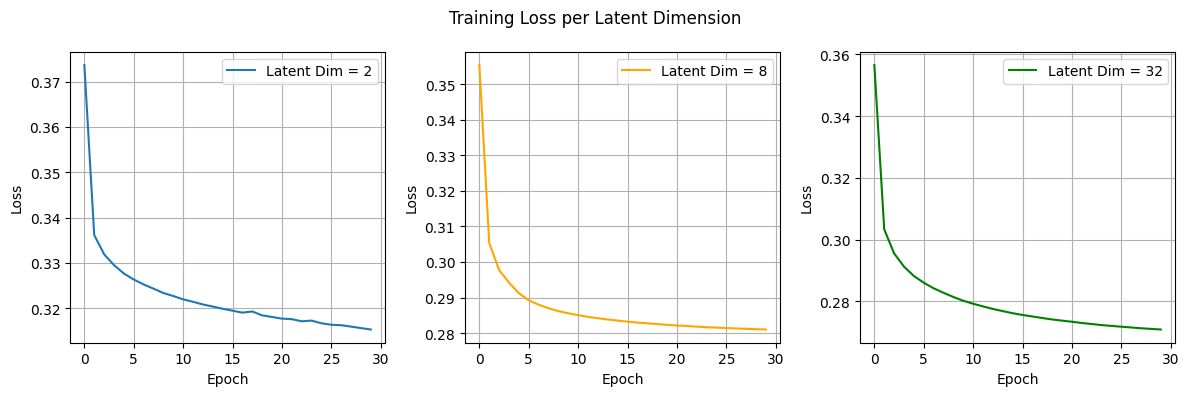

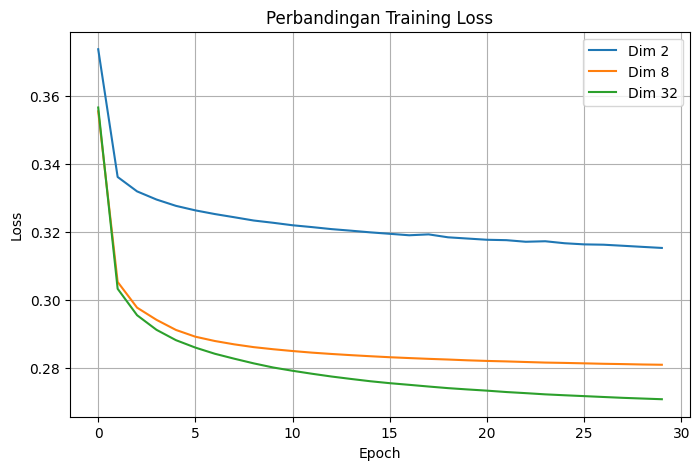

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(loss_dim2, label="Latent Dim = 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(loss_dim8, label="Latent Dim = 8", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(loss_dim32, label="Latent Dim = 32", color="green")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.suptitle("Training Loss per Latent Dimension")
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss_dim2, label="Dim 2")
plt.plot(loss_dim8, label="Dim 8")
plt.plot(loss_dim32, label="Dim 32")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Training Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_comparison.png", dpi=150)
plt.show()

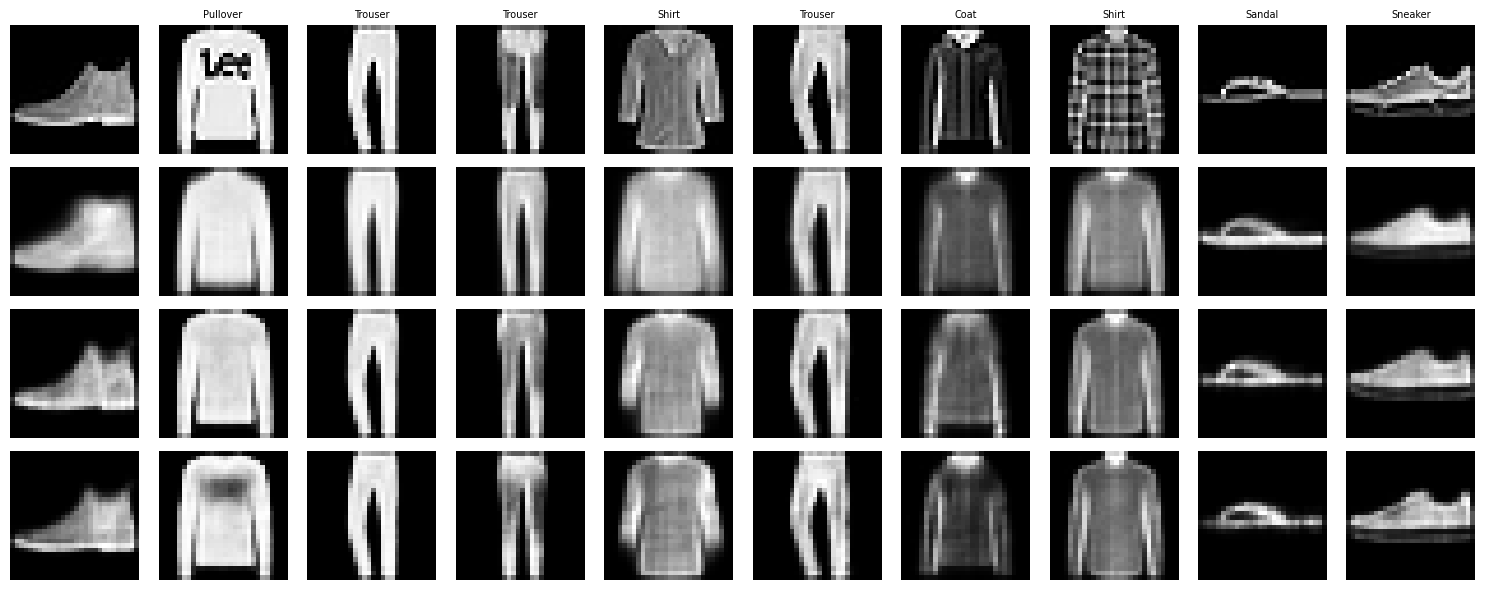

In [9]:
def show_reconstructions(models, labels, num_samples=10):
    fig, axes = plt.subplots(4, num_samples, figsize=(num_samples * 1.5, 6))
    dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

    classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

    for i in range(num_samples):
        img, label = dataset[i]
        img_flat = img.view(1, -1).to(device)

        axes[0, i].imshow(img.squeeze(), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_ylabel(f"Asli\n{classes[label]}", fontsize=8)
        else:
            axes[0, i].set_title(classes[label], fontsize=7)

        for row, (model, name) in enumerate(models):
            model.eval()
            with torch.no_grad():
                out = model(img_flat)
            recon = out.view(28, 28).cpu()
            axes[row + 1, i].imshow(recon, cmap="gray")
            axes[row + 1, i].axis("off")
            if i == 0:
                axes[row + 1, i].set_ylabel(name, fontsize=8)

    plt.tight_layout()
    plt.savefig("reconstructions_comparison.png", dpi=150)
    plt.show()


models = [
    (model_dim2, "Dim 2"),
    (model_dim8, "Dim 8"),
    (model_dim32, "Dim 32"),
]
show_reconstructions(models, ["Dim 2", "Dim 8", "Dim 32"])

In [10]:
print("=" * 60)
print("HASIL TRAINING SELESAI")
print("=" * 60)
print(f"Dim 2  — Loss akhir: {loss_dim2[-1]:.6f}")
print(f"Dim 8  — Loss akhir: {loss_dim8[-1]:.6f}")
print(f"Dim 32 — Loss akhir: {loss_dim32[-1]:.6f}")
print("=" * 60)
print("\nFile model yang disimpan:")
for f in ["autoencoder_dim2.pth", "autoencoder_dim8.pth", "autoencoder_dim32.pth",
          "decoder_dim2.pth", "decoder_dim8.pth", "decoder_dim32.pth"]:
    size = os.path.getsize(f) / 1024
    print(f"  {f} ({size:.1f} KB)")
print("\nSelesai! Download file .pth untuk digunakan di terminal.")

HASIL TRAINING SELESAI
Dim 2  — Loss akhir: 0.315293
Dim 8  — Loss akhir: 0.280995
Dim 32 — Loss akhir: 0.270877

File model yang disimpan:
  autoencoder_dim2.pth (1707.8 KB)
  autoencoder_dim8.pth (1710.8 KB)
  autoencoder_dim32.pth (1722.9 KB)
  decoder_dim2.pth (856.0 KB)
  decoder_dim8.pth (857.5 KB)
  decoder_dim32.pth (863.5 KB)

Selesai! Download file .pth untuk digunakan di terminal.
